# **Superstore Analysis**

In [2]:
import pandas as pd
data = pd.read_csv('/content/Sample - Superstore.csv', encoding = 'Latin')

In [ ]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# **Dataset Overview**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
data.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [3]:
data.duplicated().sum()

np.int64(0)

**Business Insight:**

The dataset contains 9,994 retail transactions across multiple regions,
customer segments, and product categories.

No missing values or duplicate
records were found, indicating that the dataset is suitable for analysis
without extensive data cleaning.

**Sales by Region**

In [ ]:
data.groupby('Region')['Sales'].sum()

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


**Business Insight:**

The West region generated the highest total sales, followed by the East region.

This suggests that the company's strongest revenue-generating markets are
concentrated in these regions.

**Profit by Region**

In [ ]:
data.groupby('Region')['Profit'].sum()

,Profit
Region,
Central,39706.3625
East,91522.7800
South,46749.4303
West,108418.4489


**Business Insight:**
The West region produced the highest overall profit.

Combined with its strong sales performance, this indicates efficient revenue
generation and better profit retention compared to other regions.

**Profit by Category**

In [ ]:
data.groupby('Category')['Profit'].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


**Business Insight:**

Technology is the most profitable category, generating significantly higher
profit than Furniture and Office Supplies.

The company should prioritize investments in Technology products.

**Sales by Category**

In [ ]:
data.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


**Business Insight:**

Technology generates the highest sales revenue, demonstrating strong customer
demand and reinforcing its importance as a key business category.

**Sub-Category Analysis**

In [ ]:
data.groupby('Sub-Category')['Profit'].sum().sort_values()

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


**Business Insight:**

Tables, Bookcases, and Supplies are loss-making sub-categories despite
generating substantial sales. Management should investigate pricing,
discounts, and operational costs associated with these products.

**Average Discount by Sub-Category Analysis**

In [ ]:
data.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)

,Discount
Sub-Category,
Binders,0.372292
Machines,0.306087
Tables,0.261285
Bookcases,0.211140
Chairs,0.170178
Appliances,0.166524
Copiers,0.161765
Phones,0.154556
Furnishings,0.138349


**Business Insight:**

Tables and Bookcases receive some of the highest average discounts and are
also among the least profitable sub-categories. Excessive discounting may be
contributing to reduced profitability.

**Correlation Analysis**

In [5]:
data['Discount'].corr(data['Profit'])

np.float64(-0.21948745637176803)

**Business Insight:**

A negative correlation (-0.219) exists between discount and profit,
indicating that higher discounts tend to reduce profitability.

Although the relationship is not strong, discount policies should be reviewed.

**Customer Segment Analysis**

In [6]:
data.groupby('Segment')['Profit'].sum()

,Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60298.6785


**Business Insight:**

The Consumer segment contributes the highest profit and represents the
company's most valuable customer group.

Targeted marketing campaigns could
further increase profitability.

**Shipping Mode Analysis**

In [7]:
data.groupby('Ship Mode')['Profit'].sum()

,Profit
Ship Mode,
First Class,48969.8399
Same Day,15891.7589
Second Class,57446.6354
Standard Class,164088.7875


**Business Insight:**

Standard Class shipping generates the highest profit contribution,
likely due to lower fulfillment costs compared to faster shipping methods.

**Sales vs Profit**

In [ ]:
data.groupby('Sub-Category').agg(
    {'Sales':'sum',
    'Profit':'sum'}).sort_values('Profit', ascending=False)

,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78479.2060,34053.5693
Binders,203412.7330,30221.7633
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91705.1640,13059.1436


**Regional Discount Analysis**

In [ ]:
data.groupby('Region')['Discount'].mean().sort_values(ascending=False)

,Discount
Region,
Central,0.240353
South,0.147253
East,0.145365
West,0.109335


**Business Insight:**

The Central region has the highest average discount rate and one of the
lowest profit totals. This suggests that aggressive discounting may be
reducing profitability in the region.

# **Visualization**

**Sales by Region**

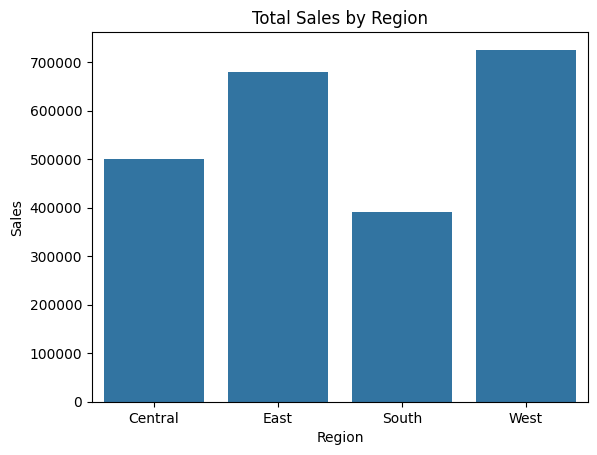

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

region_sales = data.groupby('Region', as_index = False)['Sales'].sum()
sns.barplot(x='Region',
            y='Sales', data=region_sales)
plt.title('Total Sales by Region')
plt.savefig(
    '../images/sales_by_region.png',
    bbox_inches='tight'
plt.show()

**Profit by Category**

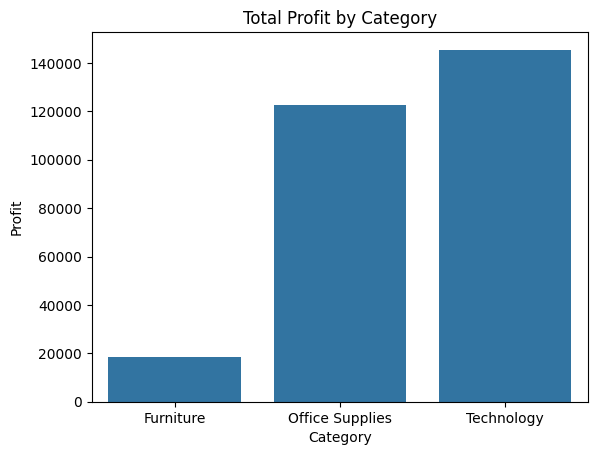

In [ ]:
category_profit = data.groupby(
    'Category',
    as_index=False
)['Profit'].sum()

sns.barplot(
    data=category_profit,
    x='Category',
    y='Profit'
)

plt.title('Total Profit by Category')
plt.savefig(
    '../images/profit_by_category.png',
    bbox_inches='tight'
plt.show()

**Top 10 Profitable Sub_Category**

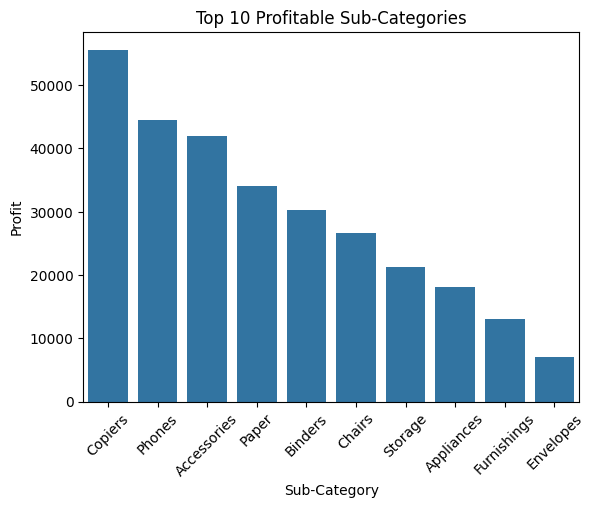

In [ ]:
top10_profit = (
    data.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(
    data=top10_profit,
    x='Sub-Category',
    y='Profit'
)

plt.xticks(rotation=45)
plt.title('Top 10 Profitable Sub-Categories')
plt.savefig(
    '../images/top_10_profitable_sub_categories.png',
    bbox_inches='tight'
plt.show()

**Discount vs Profit**

Correlation: -0.219


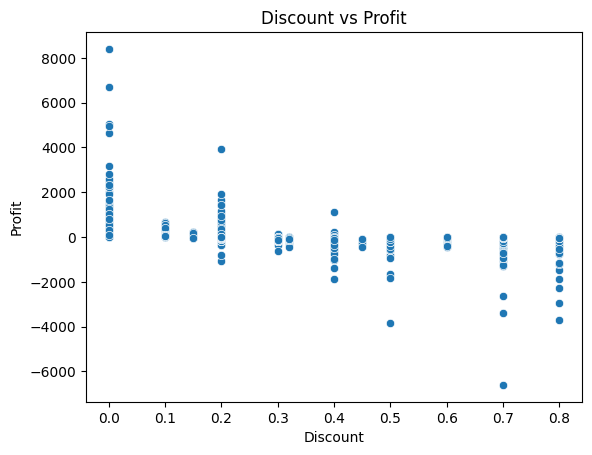

In [ ]:
corr = data['Discount'].corr(data['Profit'])

print(f"Correlation: {corr:.3f}")

sns.scatterplot(
    data=data,
    x='Discount',
    y='Profit'
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.savefig(
    '../images/discount_vs_profit.png',
    bbox_inches='tight'
plt.show()

**Profit by Sub_Category**

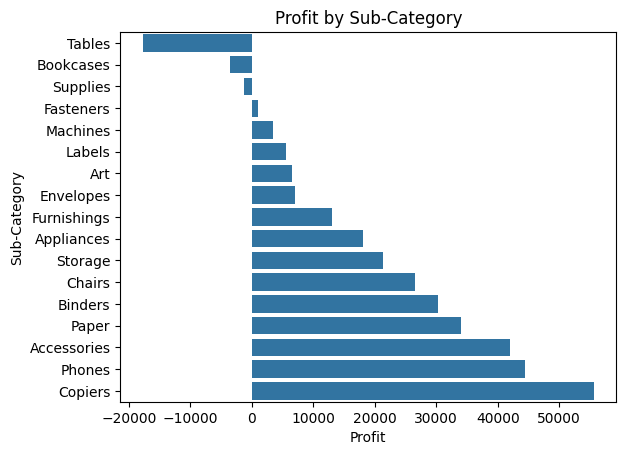

In [ ]:
subcategory_profit = (
    data.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values()
    .reset_index()
)

sns.barplot(
    data=subcategory_profit,
    x='Profit',
    y='Sub-Category'
)

plt.title('Profit by Sub-Category')
plt.savefig(
    '../images/profit_by_sub_category.png',
    bbox_inches='tight'
plt.show()

# Final Business Recommendations

1. Increase investment in Technology products due to their strong sales and profitability.

2. Focus marketing efforts on Copiers, Phones, and Accessories, which are the most profitable sub-categories.

3. Review pricing and discount strategies for Tables and Bookcases, which generate losses despite high sales.

4. Investigate the Central region's discounting practices to improve profit margins.

5. Continue targeting Consumer customers, as they contribute the highest overall profit.

6. Encourage Standard Class shipping where appropriate to maintain healthy profit margins.